# COMPLEX TERRAIN METEOROLOGY LAB
# PROMETEO FUNCTIONS IN A CUSTOM SCRIPT

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import core as core
import pre_processing as pre_processing
import frame as frame
import matplotlib.dates as mdates

##### The logger is the way the computer communicate to the user (it's not essential)

In [8]:
# logger configuration
import logging

logger = logging.getLogger("notebook_logger")
logger.setLevel(logging.INFO)

handler = logging.StreamHandler()
handler.setLevel(logging.INFO)

if not logger.handlers:
    logger.addHandler(handler)

logger.propagate = False

logger.info("Logger initialized.")

Logger initialized.


Read a .csv file as Pandas Dataframe

In [9]:
# data import
path_input = 'ES3_10_02_2012_cut/ES3_sonic_05_2012-10-02.csv'
ES3_10m_raw= pd.read_csv(path_input, sep=",", header=0)
ES3_10m_raw["Time"] = pd.to_datetime(ES3_10m_raw["Time"]) #set the timestamp column as index
ES3_10m_raw.set_index("Time", inplace=True)

How to visualize rapidly some info about the dataframe

In [10]:
# ES3_10m_raw.info()
# ES3_10m_raw.dtypes

In [11]:
ES3_10m_raw

,u,v,w,T_s
Time,,,,
2012-10-02 00:30:00.000,-0.145,0.479,-0.026,296.60001
2012-10-02 00:30:00.050,-0.146,0.480,-0.027,296.60001
2012-10-02 00:30:00.100,-0.101,0.480,-0.026,296.60001
2012-10-02 00:30:00.150,-0.148,0.479,0.050,296.50000
2012-10-02 00:30:00.200,-0.158,0.431,0.026,296.50000
...,...,...,...,...
2012-10-02 04:29:59.800,-2.434,-0.481,-0.257,291.70001
2012-10-02 04:29:59.850,-2.417,-0.482,-0.087,291.70001
2012-10-02 04:29:59.900,-2.418,-0.390,-0.038,291.70001


### Basic DataFrame manipulation

- concatenating DataFrames (if they have the same columns, a third one is constructed putting the second below the first):

```python
df_concat = pd.concat([df1, df2], ignore_index=True)
```

- adding a new column:
```python
# computed from other columns
df['C'] = df ['A'] + df['B']
df['C'] = np.zeros(...)
```

- removing a column:
`df_2 = df.drop(columns=[column_name_string_list])`

- renaming columns
`df_renamed = df.rename(columns={"A": "alpha", "B": "beta"})`

#### Slicing: selecting rows and columns

- Selecting columns by name: `df[["A", "B"]]`

- Selecting rows by index range: `df[0:3]`

- Using .loc (label-based): `df.loc[1:3, ["A", "C"]]`

- Using .iloc (position-based): `df.iloc[0:2, 0:2]`


#### Cutting the dataframe to a specific time window:
```python
start_cut = pd.to_datetime("2012-10-02 02:00:00")
end_cut = pd.to_datetime("2012-10-02 04:00:00")
df_cut = df_resampled.loc[start_cut:end_cut]
df_cut
```

### PLOT: input data

This cell shows the basic syntax of `matplotlib` (specifically: `plt.subplots()`).

- Every plot requires a figure (`fig`) and axes (`ax`)
- `ax.plot(x, y)`: line plot  (repeating the command, new curves/lines are added to the plot)
- `ax.scatter(x, y)`: scatter plot  
- `ax.set_xlabel()`, `ax.set_ylabel()`: axis labels  
- `ax.set_title()`: add a title  
- `ax.legend()`: add a legend to the axes  
- `fig.set_size_inches()`: control the size of the figure


Matplotlib provides specialized locators and formatters for dates and times:
- **Locators** control where ticks appear.
  - `mdates.MinuteLocator(interval=30)` - a tick every 30 minutes  
  - `mdates.HourLocator(interval=1)` - a tick every hour  
  - `mdates.DayLocator()`, `mdates.MonthLocator()`, etc.  

- **Formatters** control how tick labels look.
  - `mdates.DateFormatter("%H:%M")` - time in hours:minutes  
  - `mdates.DateFormatter("%Y-%m-%d %H:%M")` - full timestamp  

Apply them to the axes using: `ax.xaxis.set_major_locator(...)` and `ax.xaxis.set_major_formatter(...)`.


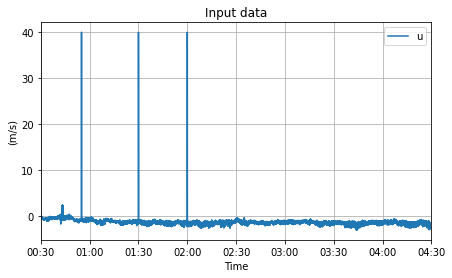

In [12]:
# Create a figure and axes 
fig, ax = plt.subplots(figsize=(7, 4))

# Line plot
ax.plot(ES3_10m_raw.index, ES3_10m_raw['u'], label='u')
# ax.plot(ES3_10m_raw.index, ES3_10m_raw['v'], label='v')
# ax.plot(ES3_10m_raw.index, ES3_10m_raw['w'], label='w')

# Axis labels and title
ax.set_xlabel("Time")
ax.set_ylabel("(m/s)")
ax.set_title("Input data")
# Legend
ax.legend()
# Grid
ax.grid()

# set axis limits
ax.set_xlim([ES3_10m_raw.index.min(), ES3_10m_raw.index.max()]) # more compact view

# Set tick frequency
locator = mdates.MinuteLocator(interval=30) # every 30 minutes
ax.xaxis.set_major_locator(locator)

# Set tick label format
formatter = mdates.DateFormatter("%H:%M") # only hours and minutes
ax.xaxis.set_major_formatter(formatter)

plt.show()

### Boolean masks in DataFrames

A *mask* is a sequence of boolean values (`True`/`False`) used to filter rows in a DataFrame.

#### Logical operators for comparisons:
- `==` equal to  
- `!=` not equal  
- `>` greater than  
- `<` less than  
- `>=`, `<=`

#### Logical operators for combining conditions:
- `&` logical AND  
- `|` logical OR  
- `~` logical NOT  

Important: when combining conditions, parentheses are required:
```python
(df["col"] > 0) & (df["col"] < 10)
```

#### Working with NaN:
- Any comparison with `NaN` returns **False**, including `NaN == NaN`.
- Operations involving `NaN` typically return `NaN`.

Example:
```python
np.nan == np.nan       # False
np.nan > 3             # False
np.nan < 100           # False
```

#### Using masks to filter a DataFrame

```python
mask = (df["A"] > 5) & df["B"].notna()
df_filtered = df[mask]
df_filtered 
```

Masks can be used with `.loc`:
```python
df.loc[mask, "A"]
df.loc[mask, ["A", "B"]]
```

In the last cases, the filtering is applied to specific columns (not to all the dataframe).

### Block statistics with Pandas

Hot to compute block averages, standard deviations and how to implement a custom function using apply to compute desired variables inside each block.

```python
blocks = df.resample("30min")
```
This does not compute anything yet. It creates groups of rows corresponding to each 30-min interval.

To compute the mean of each block: `block_means = blocks.mean()`

Or to compute standard deviations: `block_stds = blocks.std()`


Computing fluctuations using `apply`. You have to define a function to apply:

```python
def compute_fluctuations(block):
    """
    Returns fluctuations of u
    """
    u_prime = block["u"] - block["u"].mean()
    return pd.DataFrame({"u_prime": u_prime})
```
Then apply it with: `fluctuations = blocks.apply(compute_fluctuations)`

In [33]:
# example of block computations on the input data (do not take as reference for actual processing)

u_block_mean = ES3_10m_raw['u'].resample('10min').mean()  # block mean over 60 minutes
print("u block mean over 10 min:")
print(u_block_mean)

u block mean over 10 min:
Time
2012-10-02 00:30:00    0.036308
2012-10-02 00:40:00    0.284516
2012-10-02 00:50:00   -0.395173
2012-10-02 01:00:00   -0.593718
2012-10-02 01:10:00   -0.614761
2012-10-02 01:20:00   -1.096960
2012-10-02 01:30:00   -1.490007
2012-10-02 01:40:00   -1.452764
2012-10-02 01:50:00   -1.627416
2012-10-02 02:00:00   -1.611939
2012-10-02 02:10:00   -1.847541
2012-10-02 02:20:00   -1.469189
2012-10-02 02:30:00   -0.569357
2012-10-02 02:40:00   -0.633749
2012-10-02 02:50:00   -1.288730
2012-10-02 03:00:00   -1.369869
2012-10-02 03:10:00   -1.352210
2012-10-02 03:20:00   -1.371917
2012-10-02 03:30:00   -1.593755
2012-10-02 03:40:00   -2.016101
2012-10-02 03:50:00   -1.796688
2012-10-02 04:00:00   -1.902820
2012-10-02 04:10:00   -2.158624
2012-10-02 04:20:00   -2.462284
2012-10-02 04:30:00   -3.087000
Freq: 10min, Name: u, dtype: float64


In [34]:
def compute_fluctuations(block):
    """
    Returns fluctuations of u
    """
    u_prime = block["u"] - block["u"].mean()
    return pd.DataFrame({"u_prime": u_prime})
u_fluctuations = ES3_10m_raw.resample('10min').apply(compute_fluctuations)
print("u fluctuations:")
print(u_fluctuations)

u fluctuations:
                          u_prime
Time                             
2012-10-02 00:30:00.000  0.183692
2012-10-02 00:30:00.050  0.183692
2012-10-02 00:30:00.100  0.086692
2012-10-02 00:30:00.150  0.123692
2012-10-02 00:30:00.200  0.183692
...                           ...
2012-10-02 04:29:59.800 -0.673716
2012-10-02 04:29:59.850 -0.671716
2012-10-02 04:29:59.900 -0.697716
2012-10-02 04:29:59.950 -0.623716
2012-10-02 04:30:00.000  0.000000

[287701 rows x 1 columns]


To compute second order statistics you should change the definition of the function above accordingly.

### PRE-PROCESSING STEPS

In [13]:
# fill missing timestamps
ES3_10m_complete = pre_processing.fill_missing_timestamps(ES3_10m_raw, freq=20)
time = ES3_10m_complete.index # it is convenient to have the time index as a separate variable

In [14]:
# counting missing timestamps
print(f"Points in the rawdata: {len(ES3_10m_raw)}")
print(f"Points after filling timestamps procedure: {len(ES3_10m_complete)}")

Points in the rawdata: 287641
Points after filling timestamps procedure: 288001


In [15]:
# identify missing timestamps location
ES3_missing_timestamps = ~ES3_10m_complete.index.isin(ES3_10m_raw.index) # mask camparing filled timestamps with the original timestamps
sum(ES3_missing_timestamps) # number of missing timestamps

np.int64(360)

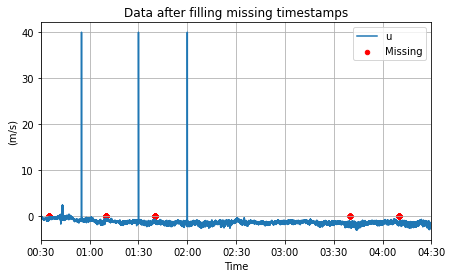

In [16]:
# plot to visualize missing timestamps
fig, ax = plt.subplots(figsize=(7, 4))
ax.grid()
ax.plot(ES3_10m_complete.index, ES3_10m_complete['u'], label='u')
ax.scatter(ES3_10m_complete.index[ES3_missing_timestamps], np.zeros(sum(ES3_missing_timestamps)), color='red', label='Missing', s=20)
ax.set_xlabel("Time")
ax.set_ylabel("(m/s)")
ax.set_title("Data after filling missing timestamps")
ax.legend()
ax.set_xlim([ES3_10m_complete.index.min(), ES3_10m_complete.index.max()])
locator = mdates.MinuteLocator(interval=30) # every 30 minutes
ax.xaxis.set_major_locator(locator)
formatter = mdates.DateFormatter("%H:%M") # only hours and minutes
ax.xaxis.set_major_formatter(formatter)
plt.show()

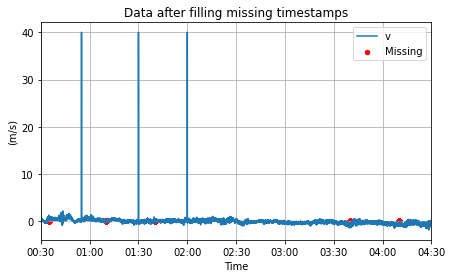

In [21]:
# plot to visualize missing timestamps
fig, ax = plt.subplots(figsize=(7, 4))
ax.grid()
ax.plot(ES3_10m_complete.index, ES3_10m_complete['v'], label='v')
ax.scatter(ES3_10m_complete.index[ES3_missing_timestamps], np.zeros(sum(ES3_missing_timestamps)), color='red', label='Missing', s=20)
ax.set_xlabel("Time")
ax.set_ylabel("(m/s)")
ax.set_title("Data after filling missing timestamps")
ax.legend()
ax.set_xlim([ES3_10m_complete.index.min(), ES3_10m_complete.index.max()])
locator = mdates.MinuteLocator(interval=30) # every 30 minutes
ax.xaxis.set_major_locator(locator)
formatter = mdates.DateFormatter("%H:%M") # only hours and minutes
ax.xaxis.set_major_formatter(formatter)
plt.show()

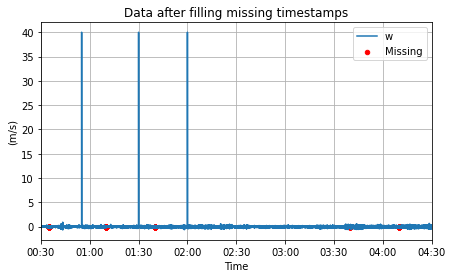

In [20]:
# plot to visualize missing timestamps
fig, ax = plt.subplots(figsize=(7, 4))
ax.grid()
ax.plot(ES3_10m_complete.index, ES3_10m_complete['w'], label='w')
ax.scatter(ES3_10m_complete.index[ES3_missing_timestamps], np.zeros(sum(ES3_missing_timestamps)), color='red', label='Missing', s=20)
ax.set_xlabel("Time")
ax.set_ylabel("(m/s)")
ax.set_title("Data after filling missing timestamps")
ax.legend()
ax.set_xlim([ES3_10m_complete.index.min(), ES3_10m_complete.index.max()])
locator = mdates.MinuteLocator(interval=30) # every 30 minutes
ax.xaxis.set_major_locator(locator)
formatter = mdates.DateFormatter("%H:%M") # only hours and minutes
ax.xaxis.set_major_formatter(formatter)
plt.show()

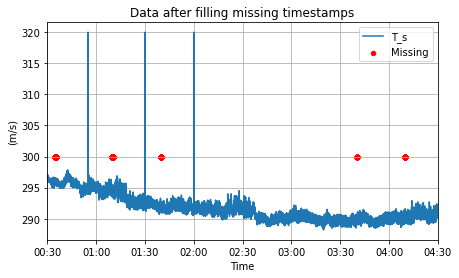

In [25]:
# plot to visualize missing timestamps
fig, ax = plt.subplots(figsize=(7, 4))
ax.grid()
ax.plot(ES3_10m_complete.index, ES3_10m_complete['T_s'], label='T_s')
ax.scatter(ES3_10m_complete.index[ES3_missing_timestamps], np.zeros(sum(ES3_missing_timestamps))+300, color='red', label='Missing', s=20)
ax.set_xlabel("Time")
ax.set_ylabel("(m/s)")
ax.set_title("Data after filling missing timestamps")
ax.legend()
ax.set_xlim([ES3_10m_complete.index.min(), ES3_10m_complete.index.max()])
locator = mdates.MinuteLocator(interval=30) # every 30 minutes
ax.xaxis.set_major_locator(locator)
formatter = mdates.DateFormatter("%H:%M") # only hours and minutes
ax.xaxis.set_major_formatter(formatter)
plt.show()

In [27]:
# remove values beyond threshold
horizontal_threshold = 30
vertical_threshold = 4
temperature_threshold = 310

u_clean, count_beyond_u = pre_processing.remove_beyond_threshold(ES3_10m_complete["u"].to_numpy(), 
                                                               horizontal_threshold)
v_clean, count_beyond_v = pre_processing.remove_beyond_threshold(ES3_10m_complete["v"].to_numpy(), 
                                                               horizontal_threshold)
w_clean, count_beyond_w = pre_processing.remove_beyond_threshold(ES3_10m_complete["w"].to_numpy(), 
                                                               vertical_threshold)
ts_clean, count_beyond_ts = pre_processing.remove_beyond_threshold(ES3_10m_complete["T_s"].to_numpy(), 
                                                               temperature_threshold)

print(f"Removed values beyond horizontal threshold in u: {count_beyond_u}")
print(f"Removed values beyond horizontal threshold in v: {count_beyond_v}")
print(f"Removed values beyond horizontal threshold in w: {count_beyond_w}")
print(f"Removed values beyond horizontal threshold in T_s: {count_beyond_ts}")

Removed values beyond horizontal threshold in u: 6
Removed values beyond horizontal threshold in v: 6
Removed values beyond horizontal threshold in w: 6
Removed values beyond horizontal threshold in T_s: 6


In [28]:
# store each step in a new DataFrame to make comparisons easier between steps

ES3_10m_clean = pd.DataFrame({
     "u": u_clean,
     "v": v_clean,
     "w": w_clean,
     "T_s": ts_clean
 }, index=time)

PLOT AFTER ThRESHOLDING

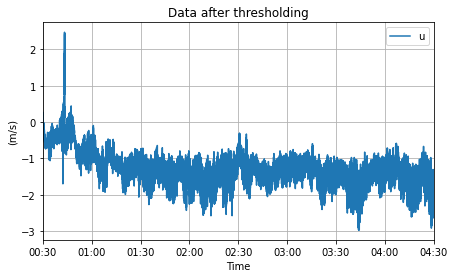

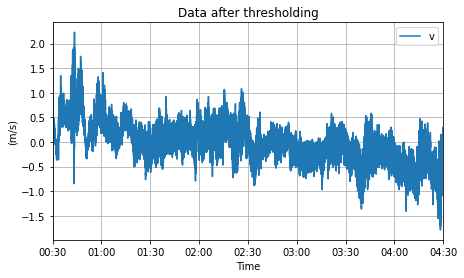

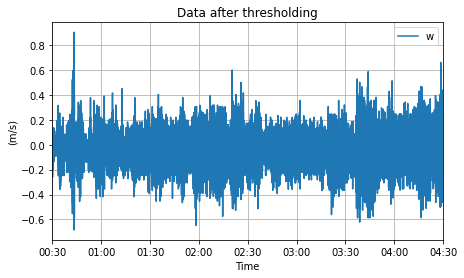

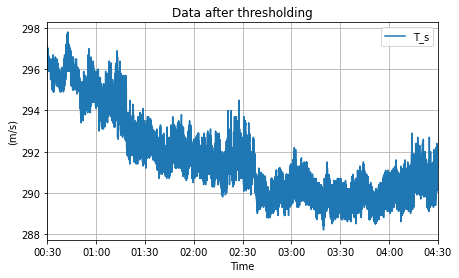

In [43]:
# plot to visualize missing timestamps
fig, ax = plt.subplots(figsize=(7, 4))
ax.grid()
ax.plot(ES3_10m_clean.index, ES3_10m_clean['u'], label='u')
#ax.scatter(ES3_10m_complete.index[ES3_missing_timestamps], np.zeros(sum(ES3_missing_timestamps))+300, color='red', label='Missing', s=20)
ax.set_xlabel("Time")
ax.set_ylabel("(m/s)")
ax.set_title("Data after thresholding")
ax.legend()
ax.set_xlim([ES3_10m_clean.index.min(), ES3_10m_clean.index.max()])
locator = mdates.MinuteLocator(interval=30) # every 30 minutes
ax.xaxis.set_major_locator(locator)
formatter = mdates.DateFormatter("%H:%M") # only hours and minutes
ax.xaxis.set_major_formatter(formatter)
plt.show()

# plot to visualize missing timestamps
fig, ax = plt.subplots(figsize=(7, 4))
ax.grid()
ax.plot(ES3_10m_clean.index, ES3_10m_clean['v'], label='v')
#ax.scatter(ES3_10m_complete.index[ES3_missing_timestamps], np.zeros(sum(ES3_missing_timestamps))+300, color='red', label='Missing', s=20)
ax.set_xlabel("Time")
ax.set_ylabel("(m/s)")
ax.set_title("Data after thresholding")
ax.legend()
ax.set_xlim([ES3_10m_clean.index.min(), ES3_10m_clean.index.max()])
locator = mdates.MinuteLocator(interval=30) # every 30 minutes
ax.xaxis.set_major_locator(locator)
formatter = mdates.DateFormatter("%H:%M") # only hours and minutes
ax.xaxis.set_major_formatter(formatter)
plt.show()

# plot to visualize missing timestamps
fig, ax = plt.subplots(figsize=(7, 4))
ax.grid()
ax.plot(ES3_10m_clean.index, ES3_10m_clean['w'], label='w')
#ax.scatter(ES3_10m_complete.index[ES3_missing_timestamps], np.zeros(sum(ES3_missing_timestamps))+300, color='red', label='Missing', s=20)
ax.set_xlabel("Time")
ax.set_ylabel("(m/s)")
ax.set_title("Data after thresholding")
ax.legend()
ax.set_xlim([ES3_10m_clean.index.min(), ES3_10m_clean.index.max()])
locator = mdates.MinuteLocator(interval=30) # every 30 minutes
ax.xaxis.set_major_locator(locator)
formatter = mdates.DateFormatter("%H:%M") # only hours and minutes
ax.xaxis.set_major_formatter(formatter)
plt.show()

# plot to visualize missing timestamps
fig, ax = plt.subplots(figsize=(7, 4))
ax.grid()
ax.plot(ES3_10m_clean.index, ES3_10m_clean['T_s'], label='T_s')
#ax.scatter(ES3_10m_complete.index[ES3_missing_timestamps], np.zeros(sum(ES3_missing_timestamps))+300, color='red', label='Missing', s=20)
ax.set_xlabel("Time")
ax.set_ylabel("(m/s)")
ax.set_title("Data after thresholding")
ax.legend()
ax.set_xlim([ES3_10m_clean.index.min(), ES3_10m_clean.index.max()])
locator = mdates.MinuteLocator(interval=30) # every 30 minutes
ax.xaxis.set_major_locator(locator)
formatter = mdates.DateFormatter("%H:%M") # only hours and minutes
ax.xaxis.set_major_formatter(formatter)
plt.show()

DESPIKING

In [35]:
# defining despiking parameters
window_length = core.min_to_points(minutes = 5, sampling_freq = 20) # ProMeteo function to convert minutes in number of points to define a a window length
c_H = 3.5
c_V = 5
c_T = 3.5
max_consecutive_spikes = 3
max_iterations = 5

In [36]:
# despiking
u_desp = pre_processing.despiking_VM97(array_to_despike=ES3_10m_clean['u'],
                    c = c_H,
                    window_length = window_length,
                    max_consecutive_spikes = max_consecutive_spikes,
                    max_iterations = max_iterations,
                    logger = logger)



                Iteration: 0, identified and removed spikes: 47
            

                Iteration: 1, identified and removed spikes: 6
            

                Iteration: 2, identified and removed spikes: 6
            

                Iteration: 3, identified and removed spikes: 3
            

                Iteration: 4, identified and removed spikes: 6
            


In [37]:
v_desp = pre_processing.despiking_VM97(array_to_despike=ES3_10m_clean['v'],
                    c = c_H,
                    window_length = window_length,
                    max_consecutive_spikes = max_consecutive_spikes,
                    max_iterations = max_iterations,
                    logger = logger)

/home/federico/unibo/complTerrMet/sonic_data/src/pre_processing.py:186: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if mask[i]:
/home/federico/unibo/complTerrMet/sonic_data/src/pre_processing.py:204: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  left_value = array[spike_indices[0] - 1]
/home/federico/unibo/complTerrMet/sonic_data/src/pre_processing.py:205: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  right_value = array[spike_ind

In [38]:
w_desp = pre_processing.despiking_VM97(array_to_despike=ES3_10m_clean['w'],
                    c = c_V,
                    window_length = window_length,
                    max_consecutive_spikes = max_consecutive_spikes,
                    max_iterations = max_iterations,
                    logger = logger)


                Iteration: 0, identified and removed spikes: 55
            

                Iteration: 1, identified and removed spikes: 3
            

                Iteration: 2, identified and removed spikes: 0
            


In [39]:
ts_desp = pre_processing.despiking_VM97(array_to_despike=ES3_10m_clean['T_s'],
                    c = c_T,
                    window_length = window_length,
                    max_consecutive_spikes = max_consecutive_spikes,
                    max_iterations = max_iterations,
                    logger = logger)


                Iteration: 0, identified and removed spikes: 30
            

                Iteration: 1, identified and removed spikes: 5
            

                Iteration: 2, identified and removed spikes: 4
            

                Iteration: 3, identified and removed spikes: 0
            


In [44]:
ES3_10m_desp = pd.DataFrame({
     "u": u_desp,
     "v": v_desp,
     "w": w_desp,
     "T_s": ts_desp
 }, index=time)
ES3_10m_desp

,u,v,w,T_s
2012-10-02 00:30:00.000,-0.145,0.479,-0.026,296.60001
2012-10-02 00:30:00.050,-0.146,0.480,-0.027,296.60001
2012-10-02 00:30:00.100,-0.101,0.480,-0.026,296.60001
2012-10-02 00:30:00.150,-0.148,0.479,0.050,296.50000
2012-10-02 00:30:00.200,-0.158,0.431,0.026,296.50000
...,...,...,...,...
2012-10-02 04:29:59.800,-2.434,-0.481,-0.257,291.70001
2012-10-02 04:29:59.850,-2.417,-0.482,-0.087,291.70001
2012-10-02 04:29:59.900,-2.418,-0.390,-0.038,291.70001
2012-10-02 04:29:59.950,-2.412,-0.218,-0.086,291.60001


PLOT AFTER DESPIKING

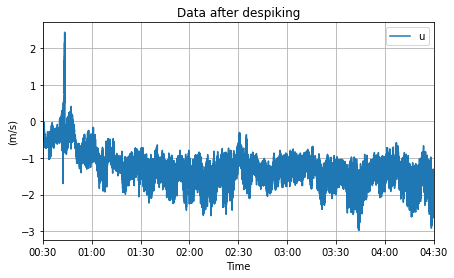

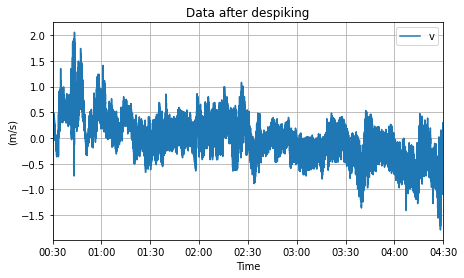

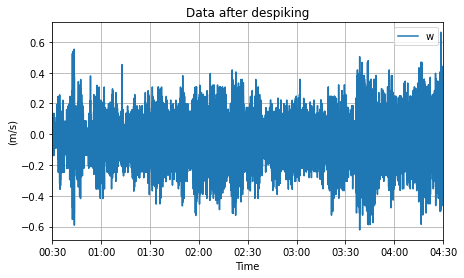

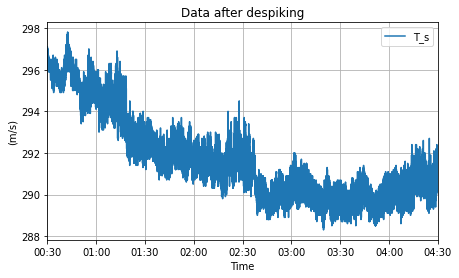

In [46]:
# plot to visualize missing timestamps
fig, ax = plt.subplots(figsize=(7, 4))
ax.grid()
ax.plot(ES3_10m_desp.index, ES3_10m_desp['u'], label='u')
#ax.scatter(ES3_10m_complete.index[ES3_missing_timestamps], np.zeros(sum(ES3_missing_timestamps))+300, color='red', label='Missing', s=20)
ax.set_xlabel("Time")
ax.set_ylabel("(m/s)")
ax.set_title("Data after despiking")
ax.legend()
ax.set_xlim([ES3_10m_desp.index.min(), ES3_10m_desp.index.max()])
locator = mdates.MinuteLocator(interval=30) # every 30 minutes
ax.xaxis.set_major_locator(locator)
formatter = mdates.DateFormatter("%H:%M") # only hours and minutes
ax.xaxis.set_major_formatter(formatter)
plt.show()

# plot to visualize missing timestamps
fig, ax = plt.subplots(figsize=(7, 4))
ax.grid()
ax.plot(ES3_10m_desp.index, ES3_10m_desp['v'], label='v')
#ax.scatter(ES3_10m_complete.index[ES3_missing_timestamps], np.zeros(sum(ES3_missing_timestamps))+300, color='red', label='Missing', s=20)
ax.set_xlabel("Time")
ax.set_ylabel("(m/s)")
ax.set_title("Data after despiking")
ax.legend()
ax.set_xlim([ES3_10m_desp.index.min(), ES3_10m_desp.index.max()])
locator = mdates.MinuteLocator(interval=30) # every 30 minutes
ax.xaxis.set_major_locator(locator)
formatter = mdates.DateFormatter("%H:%M") # only hours and minutes
ax.xaxis.set_major_formatter(formatter)
plt.show()

# plot to visualize missing timestamps
fig, ax = plt.subplots(figsize=(7, 4))
ax.grid()
ax.plot(ES3_10m_desp.index, ES3_10m_desp['w'], label='w')
#ax.scatter(ES3_10m_complete.index[ES3_missing_timestamps], np.zeros(sum(ES3_missing_timestamps))+300, color='red', label='Missing', s=20)
ax.set_xlabel("Time")
ax.set_ylabel("(m/s)")
ax.set_title("Data after despiking")
ax.legend()
ax.set_xlim([ES3_10m_desp.index.min(), ES3_10m_desp.index.max()])
locator = mdates.MinuteLocator(interval=30) # every 30 minutes
ax.xaxis.set_major_locator(locator)
formatter = mdates.DateFormatter("%H:%M") # only hours and minutes
ax.xaxis.set_major_formatter(formatter)
plt.show()

# plot to visualize missing timestamps
fig, ax = plt.subplots(figsize=(7, 4))
ax.grid()
ax.plot(ES3_10m_desp.index, ES3_10m_desp['T_s'], label='T_s')
#ax.scatter(ES3_10m_complete.index[ES3_missing_timestamps], np.zeros(sum(ES3_missing_timestamps))+300, color='red', label='Missing', s=20)
ax.set_xlabel("Time")
ax.set_ylabel("(m/s)")
ax.set_title("Data after despiking")
ax.legend()
ax.set_xlim([ES3_10m_desp.index.min(), ES3_10m_desp.index.max()])
locator = mdates.MinuteLocator(interval=30) # every 30 minutes
ax.xaxis.set_major_locator(locator)
formatter = mdates.DateFormatter("%H:%M") # only hours and minutes
ax.xaxis.set_major_formatter(formatter)
plt.show()

In [22]:
# counting changed values for u
nan_mask_final_u = np.isnan(ES3_10m_clean['u']) & np.isnan(ES3_10m_desp['u'])
diff_mask_final_u = np.not_equal(ES3_10m_clean['u'], ES3_10m_desp['u'])
modified_mask_final_u = diff_mask_final_u & ~nan_mask_final_u
print(f"Changed values for u in the Despiking VM97 procedure: {np.sum(modified_mask_final_u)}")

Changed values for u in the Despiking VM97 procedure: 23


In [20]:
# interp missing values
# u_interp, count_interp_u = pre_processing.interp_nan(last_array)
# print(f"Interpolated values for u: {count_interp_u}")


In [ ]:
# ES3_10m_preprocessed = pd.DataFrame({
#     "u": u_interp,
#     "v": v_interp,
#     "w": w_interp,
#     "T_s": T_s_interp
# }, index=time)


In [ ]:
# saving DataFrame to csv
# ES3_10m_preprocessed.to_csv('path')

Frame rotation

In [30]:
# frame rotation in streamline frame
sampling_freq = 20  # Hz
window_length_averaging = 5   # minutes
window_avg_points = core.min_to_points(sampling_freq, window_length_averaging)

azimuth = 0  # degrees
model = 'RM_YOUNG_81000'
wind_dir_threshold = 0.01  # m/s

wind = np.array([ES3_10m_preprocessed['u'].to_numpy(),
                 ES3_10m_preprocessed['v'].to_numpy(),
                ES3_10m_preprocessed['w'].to_numpy()])
wind_averaged = np.zeros_like(wind)

    # if reference_frame == "LEC":
    #     # Rotation to Local Earth Coordinate (LEC) system
    #     wind_rotated = frame.rotation_to_LEC_reference(wind, azimuth, model)
    #     for i in range(3):
    #         wind_averaged[i, :], _ = core.running_stats(wind_rotated[i, :], window_avg_points)
    #     wind_direction = frame.wind_dir_LEC_reference(wind_averaged[0], wind_averaged[1], wind_dir_threshold)

# Rotation to streamline reference frame
for i, comp in enumerate(['u', 'v', 'w']):
    # mean wind computation
    wind_averaged[i, :], _ = core.running_stats(ES3_10m_preprocessed[comp].to_numpy(), window_avg_points)

wind_rotated = frame.rotation_to_streamline_reference(wind, wind_averaged)

Wind direction computation

In [ ]:
# wind direction computation

# wind_direction = frame.wind_dir_modeldependent_reference(wind_averaged[0], wind_averaged[1], azimuth, model, wind_dir_threshold)
# del wind_averaged  # Clean up

In [ ]:
# ES3_10_final = pd.DataFrame({
#     "u": wind_rotated[0, :],
#     "v": wind_rotated[1, :],
#     "w": wind_rotated[2, :],
#     "T_s": ES3_10m_preprocessed['T_s'].to_numpy(),
#     "wind_dir": wind_direction
# }, index=time)

In [ ]:
# .csv export
# path_output = '/home/alessandro/projects/prova/ES3_10_final.csv'
# ES3_10_final.to_csv(path_output, sep=",", header=True, index=True)
# print(f"Data exported to: {path_output}")

Data exported to: /home/alessandro/projects/prova/ES3_10_final.csv
